In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print("Everything works!")

Everything works!


In [3]:
import zipfile
import os

zip_file_path = '/content/archive.zip'
extract_dir = '/content/extracted_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Archive extracted to: {extract_dir}")

Archive extracted to: /content/extracted_data


In [4]:
# List contents of the extracted directory
extracted_files = os.listdir(extract_dir)
print("Files extracted:", extracted_files)

# Find the first CSV file
csv_files = [f for f in extracted_files if f.endswith('.csv')]

if csv_files:
    csv_file_name = csv_files[0]
    csv_file_path = os.path.join(extract_dir, csv_file_name)
    print(f"Loading CSV file: {csv_file_path}")
    df = pd.read_csv(csv_file_path)
    print("DataFrame loaded successfully. Displaying the first 5 rows:")
    display(df.head())
else:
    print("No CSV files found in the extracted archive.")

Files extracted: ['Plant_2_Weather_Sensor_Data.csv', 'Plant_1_Generation_Data.csv', 'Plant_1_Weather_Sensor_Data.csv', 'Plant_2_Generation_Data.csv']
Loading CSV file: /content/extracted_data/Plant_2_Weather_Sensor_Data.csv
DataFrame loaded successfully. Displaying the first 5 rows:


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4136001,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,4136001,iq8k7ZNt4Mwm3w0,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,4136001,iq8k7ZNt4Mwm3w0,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,4136001,iq8k7ZNt4Mwm3w0,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,4136001,iq8k7ZNt4Mwm3w0,26.596148,25.088210,0.0


In [6]:
import os

print(os.listdir('/content/extracted_data'))

['Plant_2_Weather_Sensor_Data.csv', 'Plant_1_Generation_Data.csv', 'Plant_1_Weather_Sensor_Data.csv', 'Plant_2_Generation_Data.csv']


In [7]:
import pandas as pd

# Load generation data
generation_df = pd.read_csv('/content/extracted_data/Plant_1_Generation_Data.csv')

# Load weather data
weather_df = pd.read_csv('/content/extracted_data/Plant_1_Weather_Sensor_Data.csv')

# Check first rows
print("Generation Data")
display(generation_df.head())

print("Weather Data")
display(weather_df.head())

Generation Data


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


Weather Data


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [8]:
print("Generation Data Shape:", generation_df.shape)
print("Weather Data Shape:", weather_df.shape)

print("\nGeneration Columns:")
print(generation_df.columns)

print("\nWeather Columns:")
print(weather_df.columns)

Generation Data Shape: (68778, 7)
Weather Data Shape: (3182, 6)

Generation Columns:
Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD'],
      dtype='object')

Weather Columns:
Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION'],
      dtype='object')


In [9]:
print("Missing Values in Generation Data")
print(generation_df.isnull().sum())

print("\nMissing Values in Weather Data")
print(weather_df.isnull().sum())

Missing Values in Generation Data
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

Missing Values in Weather Data
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


In [10]:
# Convert datetime columns
generation_df['DATE_TIME'] = pd.to_datetime(generation_df['DATE_TIME'])
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'])

# Merge datasets
merged_df = pd.merge(
    generation_df,
    weather_df,
    on=['DATE_TIME', 'PLANT_ID'],
    how='inner'
)

# Check merged data
print("Merged Shape:", merged_df.shape)

merged_df.head()

/tmp/ipykernel_2009/3047510549.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  generation_df['DATE_TIME'] = pd.to_datetime(generation_df['DATE_TIME'])


Merged Shape: (68774, 11)


,DATE_TIME,PLANT_ID,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [11]:
merged_df.describe()


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,68774,68774.0,68774.000000,68774.000000,68774.000000,6.877400e+04,68774.000000,68774.000000,68774.000000
mean,2020-06-01 08:02:38.161514240,4135001.0,3147.177450,307.778375,3295.834644,6.978728e+06,25.558521,31.244997,0.232305
min,2020-05-15 00:00:00,4135001.0,0.000000,0.000000,0.000000,6.183645e+06,20.398505,18.140415,0.000000
25%,2020-05-24 00:33:45,4135001.0,0.000000,0.000000,0.000000,6.512007e+06,22.724491,21.123944,0.000000
50%,2020-06-01 14:15:00,4135001.0,428.571429,41.450000,2658.473214,7.146685e+06,24.670178,24.818984,0.031620
75%,2020-06-09 20:00:00,4135001.0,6365.468750,623.561161,6274.000000,7.268751e+06,27.960429,41.693659,0.454880
max,2020-06-17 23:45:00,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06,35.252486,65.545714,1.221652
std,NaN,0.0,4036.441826,394.394865,3145.220597,4.162707e+05,3.361300,12.308283,0.301948


In [12]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68774 entries, 0 to 68773
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            68774 non-null  datetime64[ns]
 1   PLANT_ID             68774 non-null  int64         
 2   SOURCE_KEY_x         68774 non-null  object        
 3   DC_POWER             68774 non-null  float64       
 4   AC_POWER             68774 non-null  float64       
 5   DAILY_YIELD          68774 non-null  float64       
 6   TOTAL_YIELD          68774 non-null  float64       
 7   SOURCE_KEY_y         68774 non-null  object        
 8   AMBIENT_TEMPERATURE  68774 non-null  float64       
 9   MODULE_TEMPERATURE   68774 non-null  float64       
 10  IRRADIATION          68774 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(2)
memory usage: 5.8+ MB


In [13]:
# Select important columns
important_columns = [
    'DC_POWER',
    'AC_POWER',
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'IRRADIATION'
]

# Correlation matrix
correlation = merged_df[important_columns].corr()

print(correlation)

                     DC_POWER  AC_POWER  AMBIENT_TEMPERATURE  \
DC_POWER             1.000000  0.999996             0.724668   
AC_POWER             0.999996  1.000000             0.724903   
AMBIENT_TEMPERATURE  0.724668  0.724903             1.000000   
MODULE_TEMPERATURE   0.954811  0.954924             0.855420   
IRRADIATION          0.989391  0.989340             0.725278   

                     MODULE_TEMPERATURE  IRRADIATION  
DC_POWER                       0.954811     0.989391  
AC_POWER                       0.954924     0.989340  
AMBIENT_TEMPERATURE            0.855420     0.725278  
MODULE_TEMPERATURE             1.000000     0.961511  
IRRADIATION                    0.961511     1.000000  


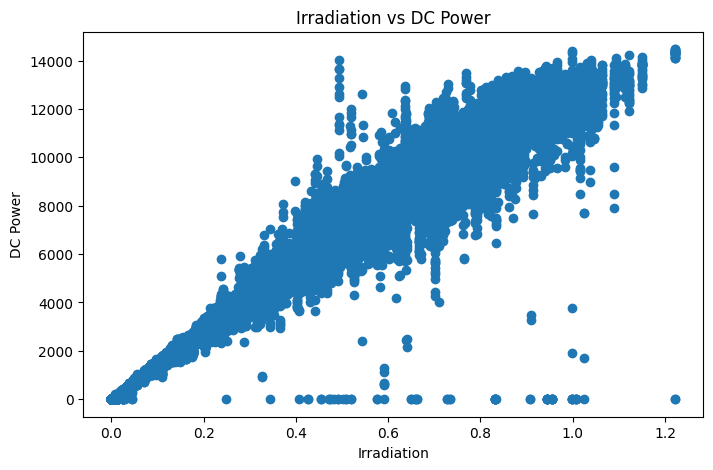

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    merged_df['IRRADIATION'],
    merged_df['DC_POWER']
)

plt.xlabel("Irradiation")
plt.ylabel("DC Power")
plt.title("Irradiation vs DC Power")

plt.show()

In [15]:
merged_df.isnull().sum()

,0
DATE_TIME,0
PLANT_ID,0
SOURCE_KEY_x,0
DC_POWER,0
AC_POWER,0
DAILY_YIELD,0
TOTAL_YIELD,0
SOURCE_KEY_y,0
AMBIENT_TEMPERATURE,0
MODULE_TEMPERATURE,0


In [16]:
# Features (X)
X = merged_df[
    [
        'AMBIENT_TEMPERATURE',
        'MODULE_TEMPERATURE',
        'IRRADIATION'
    ]
]

# Target (y)
y = merged_df['DC_POWER']

print(X.head())
print(y.head())

   AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION
0            25.184316           22.857507          0.0
1            25.184316           22.857507          0.0
2            25.184316           22.857507          0.0
3            25.184316           22.857507          0.0
4            25.184316           22.857507          0.0
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: DC_POWER, dtype: float64


In [17]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (55019, 3)
Testing data shape: (13755, 3)


In [18]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [19]:
# Predict
predictions = model.predict(X_test)

print(predictions[:10])

[10919.57699031   118.34012499  5661.79823836    54.50100535
  1004.78754516  8786.96332707  6495.11584137  1613.43085117
  3521.20610305    67.54004271]


In [20]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Evaluation metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Absolute Error: 266.36736678832636
Mean Squared Error: 321488.47740741295
R² Score: 0.9801056799671278


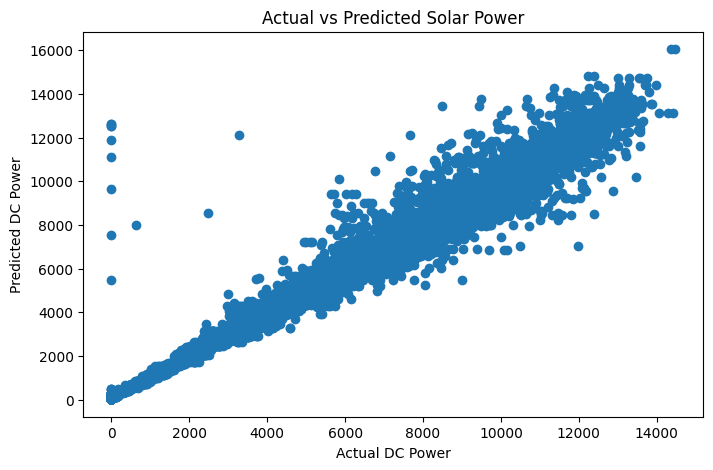

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual DC Power")
plt.ylabel("Predicted DC Power")
plt.title("Actual vs Predicted Solar Power")

plt.show()

In [22]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest R²:", rf_r2)


# XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost R²:", xgb_r2)

Random Forest R²: 0.9863742971248043
XGBoost R²: 0.9856735006290641


In [23]:
print("Linear Regression R²:", r2)
print("Random Forest R²:", rf_r2)
print("XGBoost R²:", xgb_r2)


Linear Regression R²: 0.9801056799671278
Random Forest R²: 0.9863742971248043
XGBoost R²: 0.9856735006290641


               Feature  Importance
2          IRRADIATION    0.996457
1   MODULE_TEMPERATURE    0.002066
0  AMBIENT_TEMPERATURE    0.001478


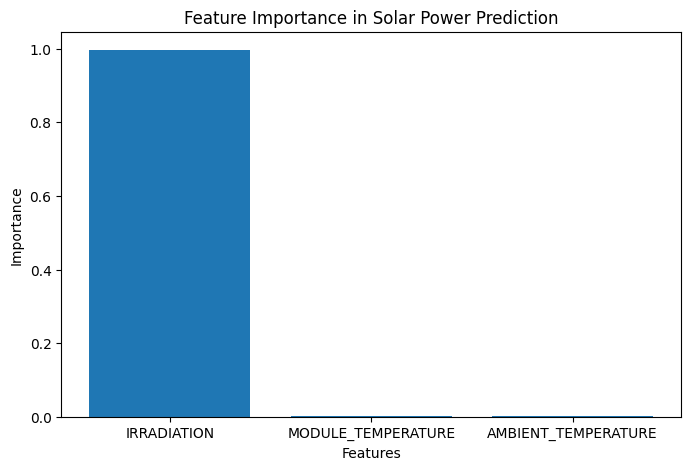

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

# Plot
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Solar Power Prediction")

plt.show()

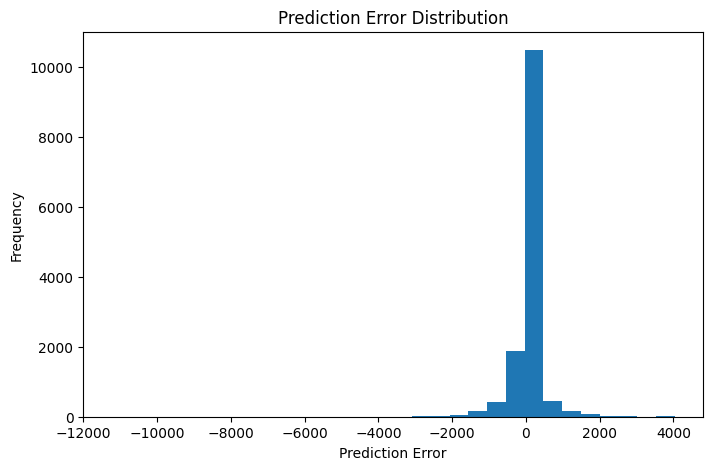

In [25]:
errors = y_test - rf_predictions

plt.figure(figsize=(8,5))

plt.hist(errors, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")

plt.show()

In [26]:
import joblib

# Save model
joblib.dump(
    rf_model,
    'solar_power_prediction_model.pkl'
)

print("Model saved successfully!")

Model saved successfully!


In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# Base model
rf = RandomForestRegressor(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

# Train
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best score
print("Best CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score:
0.9846824862014465


In [28]:
!pip install shap

In [29]:
import shap

In [3]:
import pandas as pd
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Load data again
generation_df = pd.read_csv('/content/extracted_data/Plant_1_Generation_Data.csv')
weather_df = pd.read_csv('/content/extracted_data/Plant_1_Weather_Sensor_Data.csv')

# Convert datetime
generation_df['DATE_TIME'] = pd.to_datetime(generation_df['DATE_TIME'])
weather_df['DATE_TIME'] = pd.to_datetime(weather_df['DATE_TIME'])

# Merge datasets
merged_df = pd.merge(
    generation_df,
    weather_df,
    on=['DATE_TIME', 'PLANT_ID'],
    how='inner'
)

# Features and target
X = merged_df[
    [
        'AMBIENT_TEMPERATURE',
        'MODULE_TEMPERATURE',
        'IRRADIATION'
    ]
]

y = merged_df['DC_POWER']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Random Forest again
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Everything restored successfully!")

/tmp/ipykernel_16006/1885053996.py:11: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  generation_df['DATE_TIME'] = pd.to_datetime(generation_df['DATE_TIME'])


Everything restored successfully!


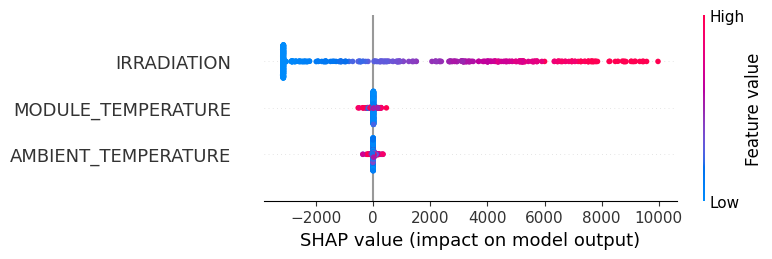

In [4]:
# SHAP sample
sample_X = X_test.sample(500, random_state=42)

# Explainer
explainer = shap.TreeExplainer(rf_model)

# SHAP values
shap_values = explainer.shap_values(sample_X)

# Plot
shap.summary_plot(
    shap_values,
    sample_X
)